# 00 · Overview of the study and the data

**Project:** *Remote sensing assessment of vegetation loss following construction of Phase 1 (Section 1) of the Lagos–Calabar Coastal Highway, Nigeria.*

This is the first of six notebooks. Together they walk through the whole analysis, from the analysis units to the final statistics, with the explanation, the code and the result of every step in one place.

| Notebook | Question it answers | Script it mirrors |
|---|---|---|
| **00 Overview and data** (this one) | What data do we have, and what does it look like? | – |
| 01 Analysis units and covariates | How were the treated and control units built, and how different were they in 2020? | `01`, `02` |
| 02 Accuracy assessment | How accurate are the land-cover maps, and how large is the true loss? | `03` |
| 03 Matching and difference-in-differences | How much vegetation loss did the highway cause? | `04`, `10` |
| 04 Vegetation fragmentation | Did the highway break up the remaining vegetation? | `05` |
| 05 Hotspots of loss | Where was loss concentrated, before and during construction? | `06` |

**Where the inputs come from.** The land-cover maps and the panel table were produced in Google Earth Engine by the scripts in `gee/` (see the README). Their outputs are stored in `data/`, so these notebooks run on any computer without Earth Engine.

**Conventions.** Dry season `DSyyyy` = 1 November of year *yyyy*−1 to 31 March of year *yyyy*. Construction started in March 2024, between DS2024 and DS2025. All spatial data are in WGS 84 / UTM zone 31N (EPSG:32631), so areas are in m² and distances in metres.

In [1]:
# --- Setup: find the repository folders (works from notebooks/ or the repo root) ---
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'python'))
from paths import DATA, VEC, RAS, TAB, VAL, RES, ZONES, CRS   # shared folder locations
warnings.filterwarnings('ignore')

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.width', 160); pd.set_option('display.max_columns', 30)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
print('Repository root found:', ROOT.name)

Repository root found: lagos-calabar-s1-vegetation-loss


## 1. The folder structure

Everything the analysis reads is in `data/`; everything it writes goes to `results/`.

In [2]:
for sub in ['vectors', 'rasters', 'tables', 'training', 'validation']:
    files = sorted(p.name for p in (DATA / sub).iterdir() if p.is_file())
    print(f'data/{sub}/  ({len(files)} files)')
    print('   ', ', '.join(files[:8]) + (' …' if len(files) > 8 else ''))

data/vectors/  (45 files)
    C_linesWest.dbf, C_linesWest.prj, C_linesWest.shp, C_linesWest.shx, ClinesEast.dbf, ClinesEast.prj, ClinesEast.shp, ClinesEast.shx …
data/rasters/  (22 files)
    Change_2020_2026_S1.tif, LC_DS2020_E.tif, LC_DS2020_S1.tif, LC_DS2020_W.tif, LC_DS2021_E.tif, LC_DS2021_S1.tif, LC_DS2021_W.tif, LC_DS2022_E.tif …
data/tables/  (5 files)
    control_screening.xlsx, imagery_log.xlsx, seg_cov.csv, segment_zone_panel_DS2020_2026.csv, strata_areas.csv
data/training/  (1 files)
    training_polygons.geojson
data/validation/  (8 files)
    accuracy_key.csv, accuracy_labels.xlsx, accuracy_points_blind.cpg, accuracy_points_blind.dbf, accuracy_points_blind.fix, accuracy_points_blind.prj, accuracy_points_blind.shp, accuracy_points_blind.shx


## 2. The panel table — the core dataset

Earth Engine measured, for **every analysis unit and every year**, the area of each land-cover class. An *analysis unit* is one 1 km segment of coastline × one distance zone:

| Zone | Meaning |
|---|---|
| `F` | the construction footprint (or, for controls, a 69.4 m pseudo-footprint) |
| `B1` | 0–500 m from the footprint edge |
| `B2` | 500 m–1 km |
| `B3` | 1–5 km |

There are 47 Section 1 segments and 110 control segments, so 157 × 4 = 628 units, observed in 7 years = 4,396 rows. Areas are in m².

In [3]:
panel = pd.read_csv(TAB / 'segment_zone_panel_DS2020_2026.csv')
print(panel.shape)
panel.head()

(4396, 17)


,unit_id,seg_id,zone,treated,side,year,a_total,a_veg,a_sand,a_beach,a_built,a_water,a_flagged,a_veg2020,a_land2020,a_veglost,elev_x_area
0,CE01_B1,CE01,B1,0,E,2023,1.434297e+06,257151.929382,602206.787275,0.0,574937.939300,0.0,0.0,292102.784884,1.434297e+06,98901.774000,9.453875e+06
1,CE01_B1,CE01,B1,0,E,2020,1.434297e+06,292102.784884,741429.537001,0.0,400764.334072,0.0,0.0,292102.784884,1.434297e+06,0.000000,9.453875e+06
2,CE01_B1,CE01,B1,0,E,2021,1.434297e+06,228943.069401,692254.697728,0.0,513098.888827,0.0,0.0,292102.784884,1.434297e+06,88928.181345,9.453875e+06
3,CE01_B1,CE01,B1,0,E,2022,1.434297e+06,316442.336328,511564.679777,0.0,606289.639851,0.0,0.0,292102.784884,1.434297e+06,70876.954571,9.453875e+06
4,CE01_B1,CE01,B1,0,E,2024,1.434297e+06,388916.423121,411633.712459,0.0,633746.520377,0.0,0.0,292102.784884,1.434297e+06,80356.442919,9.453875e+06


In [4]:
# how many units of each kind?
units = panel[panel.year == 2020]
pd.crosstab(units.side.map({'S1': 'Section 1 (treated)', 'W': 'Western controls', 'E': 'Eastern controls'}),
            units.zone, margins=True, margins_name='Total')

zone,B1,B2,B3,F,Total
side,,,,,
Eastern controls,44,44,44,44,176
Section 1 (treated),47,47,47,47,188
Western controls,66,66,66,66,264
Total,157,157,157,157,628


### The outcome variable

For unit *i* in year *t*, the outcome is the percentage of the vegetation present in DS2020 that is **no longer vegetation** in year *t*:

$$Y_{it} = 100 \times \frac{\texttt{a\_veglost}_{it}}{\texttt{a\_veg2020}_{i}}$$

It is 0 in 2020 by definition and can only be interpreted where there was some vegetation to lose, so units with less than 1 ha (10,000 m²) of DS2020 vegetation are left out.

In [5]:
p = panel[panel.a_veg2020 >= 1e4].copy()
p['Y'] = 100 * p.a_veglost / p.a_veg2020
print(f'{p.unit_id.nunique()} of {panel.unit_id.nunique()} units have at least 1 ha of vegetation in 2020')

# pooled % lost = total ha lost / total ha of 2020 vegetation, by group, zone and year
g = p.groupby(['zone', 'treated', 'year'])[['a_veglost', 'a_veg2020']].sum()
pct = (100 * g.a_veglost / g.a_veg2020).unstack('year').round(1).reset_index()
pct['zone'] = pd.Categorical(pct.zone.map(dict(ZONES)), [z for _, z in ZONES])
pct['group'] = pct.treated.map({1: 'Section 1', 0: 'Controls'})
pct.drop(columns='treated').set_index(['zone', 'group']).sort_index()

579 of 628 units have at least 1 ha of vegetation in 2020


year                  2020  2021  2022  2023  2024  2025  2026
zone       group                                              
Footprint  Controls    0.0  17.9  20.7  24.4  23.1  30.6  22.7
           Section 1   0.0   4.8  11.6  13.2  13.2  65.3  96.7
0–500 m    Controls    0.0  16.3  18.8  20.8  17.7  23.4  18.2
           Section 1   0.0   7.0  13.8  17.1  18.7  22.5  24.9
500 m–1 km Controls    0.0  13.8  18.0  18.6  13.6  18.4  15.9
           Section 1   0.0   4.8   8.1  10.6  11.2  13.4  15.1
1–5 km     Controls    0.0   9.5  12.2  12.4  10.9  12.6  11.9
           Section 1   0.0  18.9  29.4  31.3  31.8  33.8  36.1

**Reading the table.** In the footprint, Section 1 lost only 13% of its 2020 vegetation by DS2024, then 65% by DS2025 and 97% by DS2026, right after construction began. The controls stayed near 20–30% throughout. Further from the road the picture is less clear-cut, and notebook 03 tests it formally.

## 3. What the land-cover maps look like

Each map has five classes, produced by a Random Forest classifier (300 trees) in Earth Engine.

In [6]:
LC_NAMES = {1: 'Vegetation', 2: 'Sand / bare', 3: 'Beach', 4: 'Built-up', 5: 'Water'}
LC_COLS  = {0: '#FFFFFF', 1: '#2E7D32', 2: '#E8A87C', 3: '#FFF2B3', 4: '#D7301F', 5: '#C6DBEF'}
from matplotlib.colors import ListedColormap, BoundaryNorm
LC_CMAP = ListedColormap([LC_COLS[i] for i in range(6)])
LC_NORM = BoundaryNorm(np.arange(-0.5, 6.5), 6)

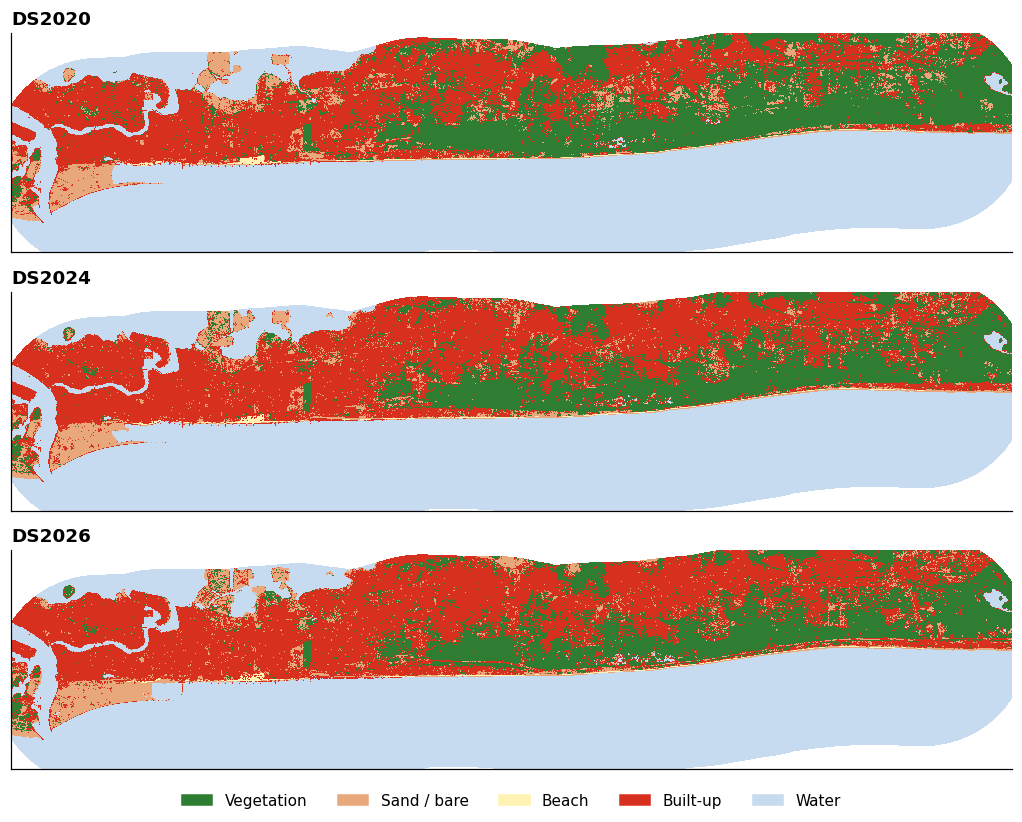

In [7]:
import rasterio
fig, axs = plt.subplots(3, 1, figsize=(12, 7.5))
for ax, y in zip(axs, [2020, 2024, 2026]):
    with rasterio.open(RAS / f'LC_DS{y}_S1.tif') as r:
        a = r.read(1); ext = [r.bounds.left, r.bounds.right, r.bounds.bottom, r.bounds.top]
    ax.imshow(a, cmap=LC_CMAP, norm=LC_NORM, extent=ext, interpolation='nearest')
    ax.set_title(f'DS{y}', loc='left', fontweight='bold'); ax.set_xticks([]); ax.set_yticks([])
from matplotlib.patches import Patch
fig.legend([Patch(color=LC_COLS[k]) for k in LC_NAMES], LC_NAMES.values(), loc='lower center', ncol=5, frameon=False)
plt.tight_layout(rect=(0, 0.04, 1, 1)); plt.show()

In [8]:
# class shares of land (water excluded) in Section 1 and its bands
rows = []
for y in range(2020, 2027):
    with rasterio.open(RAS / f'LC_DS{y}_S1.tif') as r:
        a = r.read(1)
    land = np.isin(a, [1, 2, 3, 4]).sum()
    rows.append({'year': y, **{LC_NAMES[k]: round(100 * (a == k).sum() / land, 1) for k in [1, 2, 3, 4]}})
pd.DataFrame(rows).set_index('year')

,Vegetation,Sand / bare,Beach,Built-up
year,,,,
2020,41.2,11.3,0.6,46.8
2021,35.8,10.1,0.6,53.5
2022,31.5,10.9,0.6,57.0
2023,31.3,10.8,0.6,57.2
2024,31.9,9.9,0.6,57.6
2025,30.5,11.2,0.6,57.7
2026,30.0,10.2,0.5,59.3


Across the Section 1 raster (the corridor and 5 km either side), vegetation declines and built-up land grows steadily, but most of that is the urbanisation of Lekki, which started long before the road. Separating the road's effect from that background trend is the job of the difference-in-differences design in notebook 03.

**Next:** notebook 01 builds the analysis units and describes how different Section 1 and the controls were in 2020.